In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
import scipy.interpolate as interp 
try:
    import cupy as xp
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp

from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


has cupy
has cupy
has BBHx waveform


## Data settings 

### set time and frequencies (the 0 frequency is removed)

In [2]:
t_start = 30. * DAY # start time in s
Tobs = DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 15. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# remove 0 frequency 
data_frequencies_full = data_frequencies_full[1:]
data_frequencies_full.shape 

(2880,)

### mask the "null" and out-of-band frequencies 

In [3]:
# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
# for i in range(1, 50): 
#     mask_idx = np.where(np.abs(data_frequencies_full - i*0.05)<i*3e-4)[0] # 0.025 for TDI2, 0.05 for TDI1
#     mask[mask_idx] = False 

# # remove the frequencies below Taiji sensitive band 
# mask_idx = np.where(data_frequencies_full < 1e-5)[0]
# mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]
data_frequencies_GPU = xp.array(data_frequencies)
data_frequencies_GPU.shape 

(2880,)

## Set response model 

In [4]:
# the path of Taiji orbit 
orbit_GPU = Orbit(
    OrbitDir="/home/ps/Desktop/TaijiFiducialEqualArmOrbit", # the same equal-arm orbit as used in MLST 
    dt=DAY, 
    pn_order=0, 
    ) 

# initialize  waveform generator 
WFG_GPU = BBHxWaveformGenerator(
    mode="primary", 
    use_gpu=True
    )

# initialize response generator 
FDTDI_GPU = BBHxFDTDIResponseGenerator(
    orbit_class=orbit_GPU, 
    waveform_generator=WFG_GPU, 
    use_gpu=True
    )

# response settings for MLE and data generation 
response_kwargs_GPU = dict(
    modes=[(2,2)], 
    tc_at_constellation=True, 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    TDIGeneration="1st", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    output_by_mode=False, 
    interpolation=True,
)

# response settings for heterodyned MCMC 
response_kwargs_GPU_like = dict(
    modes=[(2,2)], 
    tc_at_constellation=True, 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    TDIGeneration="1st", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    output_by_mode=False, 
    interpolation=False,
)

## Set priors for the "intrinsic" parameters
These 7 parameters will be estimated by MLE, and other parameters can be derived using the formula of F-statistics.

In [5]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [t_start/DAY+0.1, t_end/DAY-0.1] # avoid tc at the edge 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

intrinsic_param_priors

array([[ 5.5       ,  6.5       ],
       [ 0.1       ,  1.        ],
       [-0.9       ,  0.9       ],
       [-0.9       ,  0.9       ],
       [30.1       , 30.9       ],
       [ 0.        ,  6.28318531],
       [-1.        ,  1.        ]])

## Set noise model

In [6]:
PSDfunc = TDIPSDs()
PSD_channels = np.array([
    PSDfunc.PSD_A(data_frequencies), 
    PSDfunc.PSD_A(data_frequencies),
])

# covariance matrix 
CovMat = np.array([
    [PSD_channels[0], np.zeros_like(PSD_channels[0])],
    [np.zeros_like(PSD_channels[0]), PSD_channels[1]],
]) / 4. / delta_f # (2, 2, Nf)

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) # (Nf, 2, 2)

PSD_channels.shape, InvCovMat.shape 

((2, 2880), (2880, 2, 2))

## Data generation 

In [7]:
# generate source parameter and clean signal 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'coalescence_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(np.log10(6000.), 5.)), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
wf_channels = FDTDI_GPU.Response(mbhb_parameters, data_frequencies_GPU, **response_kwargs_GPU)
opt_SNR = FrequencyDomainCovarianceSNR(wf_channels.get(), InvCovMat)

# generate frequency-domain noises 
Re_tmp = np.random.normal(scale=np.sqrt(PSD_channels / 4. / delta_f))
Im_tmp = np.random.normal(scale=np.sqrt(PSD_channels / 4. / delta_f))
noise_channels = xp.array(Re_tmp + 1.j * Im_tmp) 

# combine signal and noise 
data_channels = wf_channels + noise_channels 

print("source parameters:")
for k, v in mbhb_parameters.items():
    print(k, ":", v)
print("optimal SNR:", opt_SNR)

wf_channels.shape, data_channels.shape 

source parameters:
chirp_mass : 569349.6329613862
mass_ratio : 0.7577447039321892
spin_1z : 0.027156873023373995
spin_2z : 0.8164419477586714
coalescence_time : 30.819322814646167
coalescence_phase : 4.514290754600092
luminosity_distance : 11396.99350166061
inclination : 1.908648813768427
longitude : 3.767817321866705
latitude : 0.9673212300830506
psi : 0.7137440488518518
optimal SNR: 4790.499881442073


((2, 2880), (2, 2880))

(1e-21, 1.77186782896981e-16)

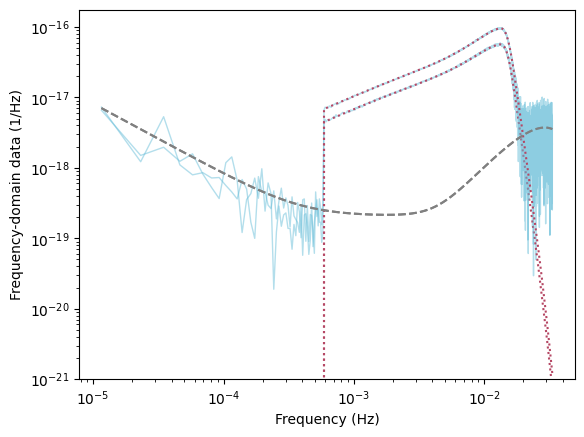

In [8]:
for ichannel, nchannel in enumerate(["A", "E"]): 
    plt.loglog(data_frequencies, np.abs(data_channels[ichannel].get()), linewidth=1, alpha=0.5, color=BLUE)
    plt.loglog(data_frequencies, np.abs(wf_channels[ichannel].get()), color=RED, linestyle=":")
    plt.loglog(data_frequencies, np.sqrt(PSD_channels[ichannel] * Tobs / 2.), color="grey", linestyle="--")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency-domain data (1/Hz)")
plt.ylim(1e-21,)

## Rapid search phase 

### initialize $\mathcal{F}$-stat and likelihood

In [9]:
Fstat = Fstatistics(
    response_generator=FDTDI_GPU, 
    frequency=data_frequencies_GPU, 
    data=data_channels, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_GPU, 
    use_gpu=True 
)



## Maximum likelihood estimation

In [10]:
from scipy.optimize import differential_evolution

def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams, Nevent), normalized to (0, 1)
    """
    try: 
        int_params = norm_int_params.transpose() * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nevent, Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params.transpose()) # (Nparams, Nevent) -> dictionary, each item (Nevent)
        return -Fstat.calculate_Fstat_vectorized(intrinsic_parameters=params_in) # (Nevent)
    except xp.linalg.LinAlgError:
        return np.infty * np.ones(norm_int_params.shape[1])

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    maxiter=1000,
    popsize=10*n_dim_int,
    tol=1e-8,
    atol=1e-10,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=True,
    vectorized=True,
)
print(DE_result)

/home/ps/miniconda3/envs/tdc/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


             message: Optimization terminated successfully.
             success: True
                 fun: -11466503.03272407
                   x: [ 2.554e-01  7.275e-01  5.249e-01  9.412e-01
                        8.992e-01  7.368e-02  4.628e-01]
                 nit: 363
                nfev: 404
          population: [[ 2.554e-01  7.275e-01 ...  7.368e-02  4.628e-01]
                       [ 2.554e-01  7.277e-01 ...  7.389e-02  4.628e-01]
                       ...
                       [ 2.554e-01  7.280e-01 ...  7.391e-02  4.625e-01]
                       [ 2.554e-01  7.278e-01 ...  7.395e-02  4.627e-01]]
 population_energies: [-1.147e+07 -1.147e+07 ... -1.147e+07 -1.147e+07]
                 jac: [-6.122e+03  4.554e+02  9.160e+02  5.759e+02
                        3.280e+04 -6.221e+01  1.416e+01]


### derive other parameters and reconstruct waveform
the truths should be near to either the searched parameters or its reflected mode 

In [11]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = Fstat.calculate_Fstat_vectorized(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic_vectorized(searched_a)
searched_params = mbhb_parameters.copy()
for key in searched_params.keys(): 
    if key in searched_int_params.keys():
        searched_params[key] = searched_int_params[key]
    elif key in searched_ext_params.keys():
        searched_params[key] = searched_ext_params[key]

searched_ref_params = get_reflected_parameter_dict(searched_params, orbit_GPU)

print("parameter name | truth | searched value | searched value (reflected mode)")
for k, v in searched_params.items():
    print(k, mbhb_parameters[k], v, searched_ref_params[k])

parameter name | truth | searched value | searched value (reflected mode)
chirp_mass 569349.6329613862 569395.7539225351 569395.7539225351
mass_ratio 0.7577447039321892 0.7547932824828003 0.7547932824828003
spin_1z 0.027156873023373995 0.04481328251095884 0.04481328251095884
spin_2z 0.8164419477586714 0.7942326384893464 0.7942326384893464
coalescence_time 30.819322814646167 30.81932297337967 30.81932297337967
coalescence_phase 4.514290754600092 2.943518682050459 2.943518682050459
luminosity_distance 11396.99350166061 11380.863200263564 11380.863200263564
inclination 1.908648813768427 1.2326934440627428 1.9088992095270503
longitude 3.767817321866705 0.46295735295522805 3.7913878676636674
latitude 0.9673212300830506 -0.07444993207638805 0.9692550001896778
psi 0.7137440488518518 0.9445867608339168 2.30051933983582


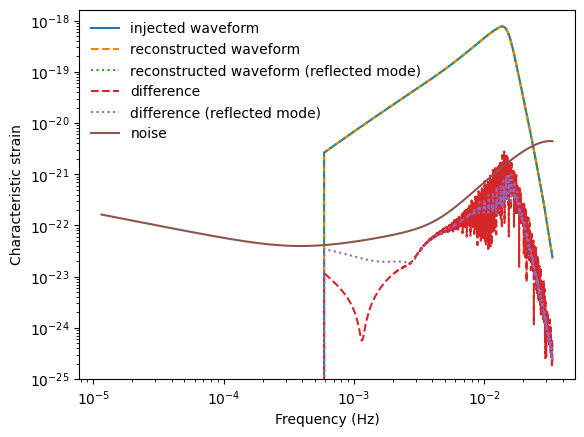

In [12]:
searched_wf = FDTDI_GPU.Response(
    searched_params, 
    data_frequencies_GPU, 
    **response_kwargs_GPU
)

searched_ref_wf = FDTDI_GPU.Response(
    searched_ref_params, 
    data_frequencies_GPU, 
    **response_kwargs_GPU
)


plt.loglog(data_frequencies, np.abs(wf_channels[0].get()) * data_frequencies, label="injected waveform")
plt.loglog(data_frequencies, np.abs(searched_wf[0].get()) * data_frequencies, linestyle="--", label="reconstructed waveform")
plt.loglog(data_frequencies, np.abs(searched_ref_wf[0].get()) * data_frequencies, linestyle=":", label="reconstructed waveform (reflected mode)")
plt.loglog(data_frequencies, np.abs(searched_wf[0].get() - wf_channels[0].get()) * data_frequencies, linestyle="--", label="difference")
plt.loglog(data_frequencies, np.abs(searched_ref_wf[0].get() - wf_channels[0].get()) * data_frequencies, linestyle=":", label="difference (reflected mode)")
plt.loglog(data_frequencies, np.sqrt(PSD_channels[0] * 2. * data_frequencies), label="noise")
plt.ylim(1e-25, )
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic strain")
plt.legend(loc="upper left", frameon=False)

## Fisher analysis 
Get the 1sigma ranges required by MCMC. 

In [13]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI_GPU.Response(
        parameters=param_dict, 
        freqs=xp.array(frequencies),  
        **response_kwargs_GPU, 
    )
    return res.get()

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'coalescence_time': 0.001,
    'coalescence_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_params, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequencies, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

In [14]:
print("parameter name | difference | difference (reflected mode) | FIM bound")
for k, v in searched_params.items():
    print(k, np.abs(v-mbhb_parameters[k]), np.abs(searched_ref_params[k] - mbhb_parameters[k]), FIM.param_errors[k])

parameter name | difference | difference (reflected mode) | FIM bound
chirp_mass 46.1209611488739 46.1209611488739 40.649672167591
mass_ratio 0.002951421449388869 0.002951421449388869 0.003189113233070809
spin_1z 0.017656409487584845 0.017656409487584845 0.01835149009499711
spin_2z 0.02220930926932496 0.02220930926932496 0.022989569212366605
coalescence_time 1.587335027863901e-07 1.587335027863901e-07 7.381320088822685e-07
coalescence_phase 1.5707720725496328 1.5707720725496328 0.0026422367471498277
luminosity_distance 16.130301397046424 16.130301397046424 31.106381398705484
inclination 0.6759553697056842 0.00025039575862328967 0.00033274494437746663
longitude 3.304859968911477 0.023570545796962605 0.007037354951887432
latitude 1.0417711621594385 0.0019337701066272084 0.006454372086678515
psi 0.23084271198206496 1.586775290983968 0.0023887664184378326


## Run MCMC with the heterodyned likelihood 

### initialize likelihood 

In [15]:
Like = Likelihood(
    response_generator=FDTDI_GPU, 
    frequency=data_frequencies_GPU, 
    data=data_channels,
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_GPU_like, 
    use_gpu=True,
)

Like.prepare_het_log_like(
    base_parameters=ParamDict2ParamArr(searched_params), 
    ) 

def eryn_like(params): 
    """params: numpy array of shape (Nevents, Nparams)"""
    # return Like.full_log_like_vectorized(np.transpose(params))
    return Like.het_log_like_vectorized(np.transpose(params))

In [16]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds
from eryn.backends import HDFBackend
from eryn.utils import SearchConvergeStopping

from corner import corner

### set MCMC prior range using the results of Fisher 
only the intrinsic parameters $\mathcal{M}_c, q, \chi_1, \chi_2$ and $t_c$ will use these prior ranges 

In [17]:
searched_param_arr = np.array(ParamDict2ParamArr(searched_params)) 
injected_param_arr = np.array(ParamDict2ParamArr(mbhb_parameters))
param_names = np.array(list(mbhb_parameters.keys()))
labels = [r'$\mathcal{M}_{c, z}$', r'$q$', r'$\chi_{z1}$', r'$\chi_{z2}$', r'$t_c$', r'$\varphi_c$', r'$D_L$', r'$\iota$', r'$\lambda$', r'$\beta$', r'$\psi$']
fim_range = []
for par in param_names:
    if par in ["chirp_mass", "luminosity_distance"]:
        ran = FIM.param_errors[par] / searched_params[par] / np.log(10.) # lg value 
    else:
        ran = FIM.param_errors[par] 
    fim_range.append(ran)
fim_range = np.array(fim_range) * 10. # ~10 sigmas

for idx, par in enumerate(param_names):
    print(par, searched_param_arr[idx], fim_range[idx])

chirp_mass 5.755414224217876 0.00031004671517031974
mass_ratio 0.7547932824828003 0.03189113233070809
spin_1z 0.04481328251095884 0.18351490094997108
spin_2z 0.7942326384893464 0.22989569212366606
coalescence_time 30.81932297337967 7.381320088822685e-06
coalescence_phase 2.943518682050459 0.026422367471498277
luminosity_distance 4.056175203086651 0.011870215427176816
inclination 0.331697976939491 0.0033274494437746664
longitude 0.46295735295522805 0.07037354951887431
latitude -0.07438117438185843 0.06454372086678514
psi 0.9445867608339168 0.023887664184378328


In [18]:
# set hyper parameters
ndim = 11 # dimension of paramters 
nwalkers = 1000 # number of random walkers
ntemps = 10 # number of temperatures used in parallel tempering 
temps = np.array(list(np.power(2., np.arange(ntemps - 1))) + [np.infty]) 
betas = 1. / temps 
tempering_kwargs=dict(betas=betas)

mcmc_moves = StretchMove(a=2) # emcee move 

stop = None 

# set a narrower prior for the instrinsic parameters, since heterodyned likelihood must be based on an initial estimation 
lim_lgMc = [searched_param_arr[0] - fim_range[0], searched_param_arr[0] + fim_range[0]]
lim_q = [max(0.1, searched_param_arr[1] - fim_range[1]), min(1., searched_param_arr[1] + fim_range[1])]
lim_chiz1 = [max(-0.9, searched_param_arr[2] - fim_range[2]), min(0.9, searched_param_arr[2] + fim_range[2])]
lim_chiz2 = [max(-0.9, searched_param_arr[3] - fim_range[3]), min(0.9, searched_param_arr[3] + fim_range[3])]
lim_tc = [searched_param_arr[4] - fim_range[4], searched_param_arr[4] + fim_range[4]]
lim_phic = [0, TWOPI]
lim_lgD = [3., 5.]
lim_cosinc = [-1, 1]
lim_lam = [0, TWOPI]
lim_sinbeta = [-1, 1]
lim_psi = [0, PI]

lims = np.array([lim_lgMc, lim_q, lim_chiz1, lim_chiz2, lim_tc, lim_phic, lim_lgD, lim_cosinc, lim_lam, lim_sinbeta, lim_psi])
lower_lims = lims[:, 0]
upper_lims = lims[:, 1]

priors_in = {i: uniform_dist(lims[i][0], lims[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)
priors.use_cupy = False

# set starting range for the initial samples 
start_lims = lims.copy()
# initialize inc, lon and lat around the searched values (3 sigmas)
start_lims[7] = np.cos(searched_params["inclination"]) + np.array([-1., 1.]) * np.abs(FIM.param_errors["inclination"] * 3. * np.sin(searched_params["inclination"]))
start_lims[8] = searched_params["longitude"] + np.array([-1., 1.]) * FIM.param_errors["longitude"] * 3.
start_lims[9] = np.sin(searched_params["latitude"]) + np.array([-1., 1.]) * np.abs(FIM.param_errors["latitude"] * 3. * np.cos(searched_params["latitude"]))
for i in range(11):
    start_lims[i][0] = max(lims[i][0], start_lims[i][0])
    start_lims[i][1] = min(lims[i][1], start_lims[i][1])
start_priors_in = {i: uniform_dist(start_lims[i][0], start_lims[i][1]) for i in range(ndim)}
start_priors = ProbDistContainer(start_priors_in)
start_priors.use_cupy = False

lims, start_lims

(array([[ 5.75510418,  5.75572427],
        [ 0.72290215,  0.78668441],
        [-0.13870162,  0.22832818],
        [ 0.56433695,  0.9       ],
        [30.81931559, 30.81933035],
        [ 0.        ,  6.28318531],
        [ 3.        ,  5.        ],
        [-1.        ,  1.        ],
        [ 0.        ,  6.28318531],
        [-1.        ,  1.        ],
        [ 0.        ,  3.14159265]]),
 array([[ 5.75510418,  5.75572427],
        [ 0.72290215,  0.78668441],
        [-0.13870162,  0.22832818],
        [ 0.56433695,  0.9       ],
        [30.81931559, 30.81933035],
        [ 0.        ,  6.28318531],
        [ 3.        ,  5.        ],
        [ 0.33075626,  0.3326397 ],
        [ 0.44184529,  0.48406942],
        [-0.09369065, -0.0550717 ],
        [ 0.        ,  3.14159265]]))

### initialize sampling points 

In [19]:
# randomize starting positions throughout prior
coords = start_priors.rvs(size=(ntemps, nwalkers,))
print("initial shape:", coords.shape)

# map half of the sky positions to the reflected mode 
for idx1 in range(coords.shape[0]):
    for idx2 in range(coords.shape[1]): 
        flag = np.random.uniform(0., 1.)
        if flag < 0.5: # half of the initial samples will be reflected 
            ref_lon, ref_lat, _, ref_inc = get_reflected_parameters(coords[idx1][idx2][8], np.arcsin(coords[idx1][idx2][9]), coords[idx1][idx2][10], np.arccos(coords[idx1][idx2][7]), searched_params["coalescence_time"]*DAY, orbit_GPU)
            coords[idx1][idx2][8] = ref_lon
            coords[idx1][idx2][9] = np.sin(ref_lat)
            coords[idx1][idx2][7] = np.cos(ref_inc) # if inclination is initialized 

initial shape: (10, 1000, 11)


In [20]:
((lims.T - injected_param_arr)[0] < 0.).all(), ((lims.T - injected_param_arr)[1] > 0.).all()

(True, True)

In [21]:
((start_lims.T - injected_param_arr)[0] < 0.).all(), ((start_lims.T - injected_param_arr)[1] > 0.).all()

(False, False)

### initialize sampler 

In [22]:
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    eryn_like, 
    priors,
    args=[],
    tempering_kwargs=tempering_kwargs,
    stopping_fn=stop,
    stopping_iterations=10,
    moves=mcmc_moves,
    vectorize=True,
)

### Run MCMC 

In [23]:
thin_by = 100 
burn = 0
nsteps = int(20000 / thin_by) # should be more than enough 

ensemble.stopping_fn = None

out = ensemble.run_mcmc(coords, nsteps, burn=burn, progress=True, thin_by=thin_by)

100%|██████████| 20000/20000 [40:38<00:00,  8.20it/s]


In [28]:
# # resume run after the run is stopped 
# thin_by =100
# burn = 0
# nsteps = int(50000 / thin_by) # this should be far more than enough 

# out = ensemble.run_mcmc(ensemble.get_last_sample(), nsteps, burn=burn, progress=True, thin_by=thin_by)

<Figure size 640x480 with 0 Axes>

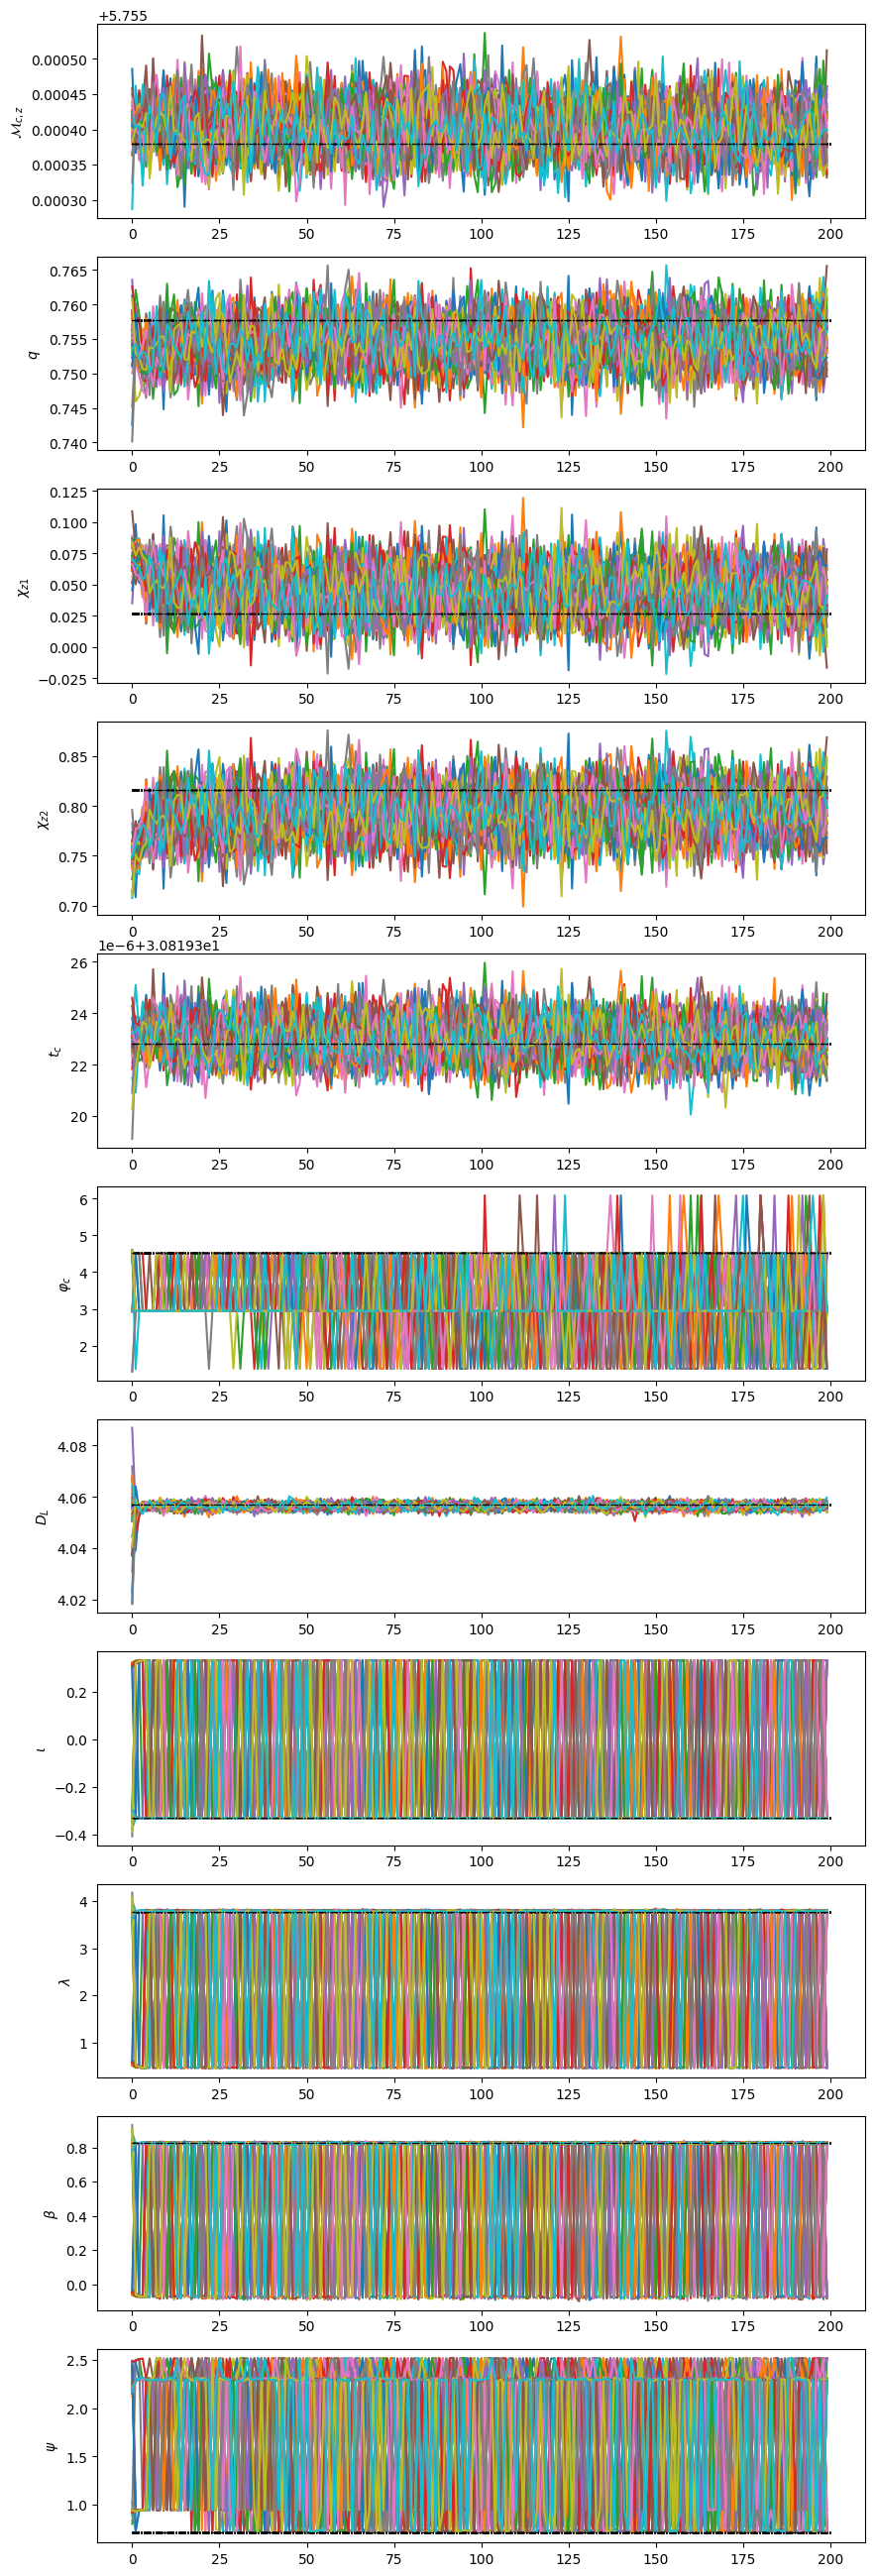

In [29]:
thin = 1
burnin = 0
len_chain = len(ensemble.get_chain(thin=thin, discard=burnin)['model_0'][:, 0, 0, :, 0])

plt.figure()
fig, ax = plt.subplots(ndim, 1)
fig.set_size_inches(10, 3*ndim)
for i in range(ndim):     
    for walk in range(50): # plot 20 walkers 
        ax[i].plot(ensemble.get_chain(thin=thin, discard=burnin)['model_0'][:, 0, walk, 0, i])
        ax[i].hlines(injected_param_arr[i], 0, len_chain, color='k', linestyle='-.', linewidth=0.8)
    ax[i].set_ylabel(labels[i])


sample shape: (10000, 11)


<Figure size 640x480 with 0 Axes>

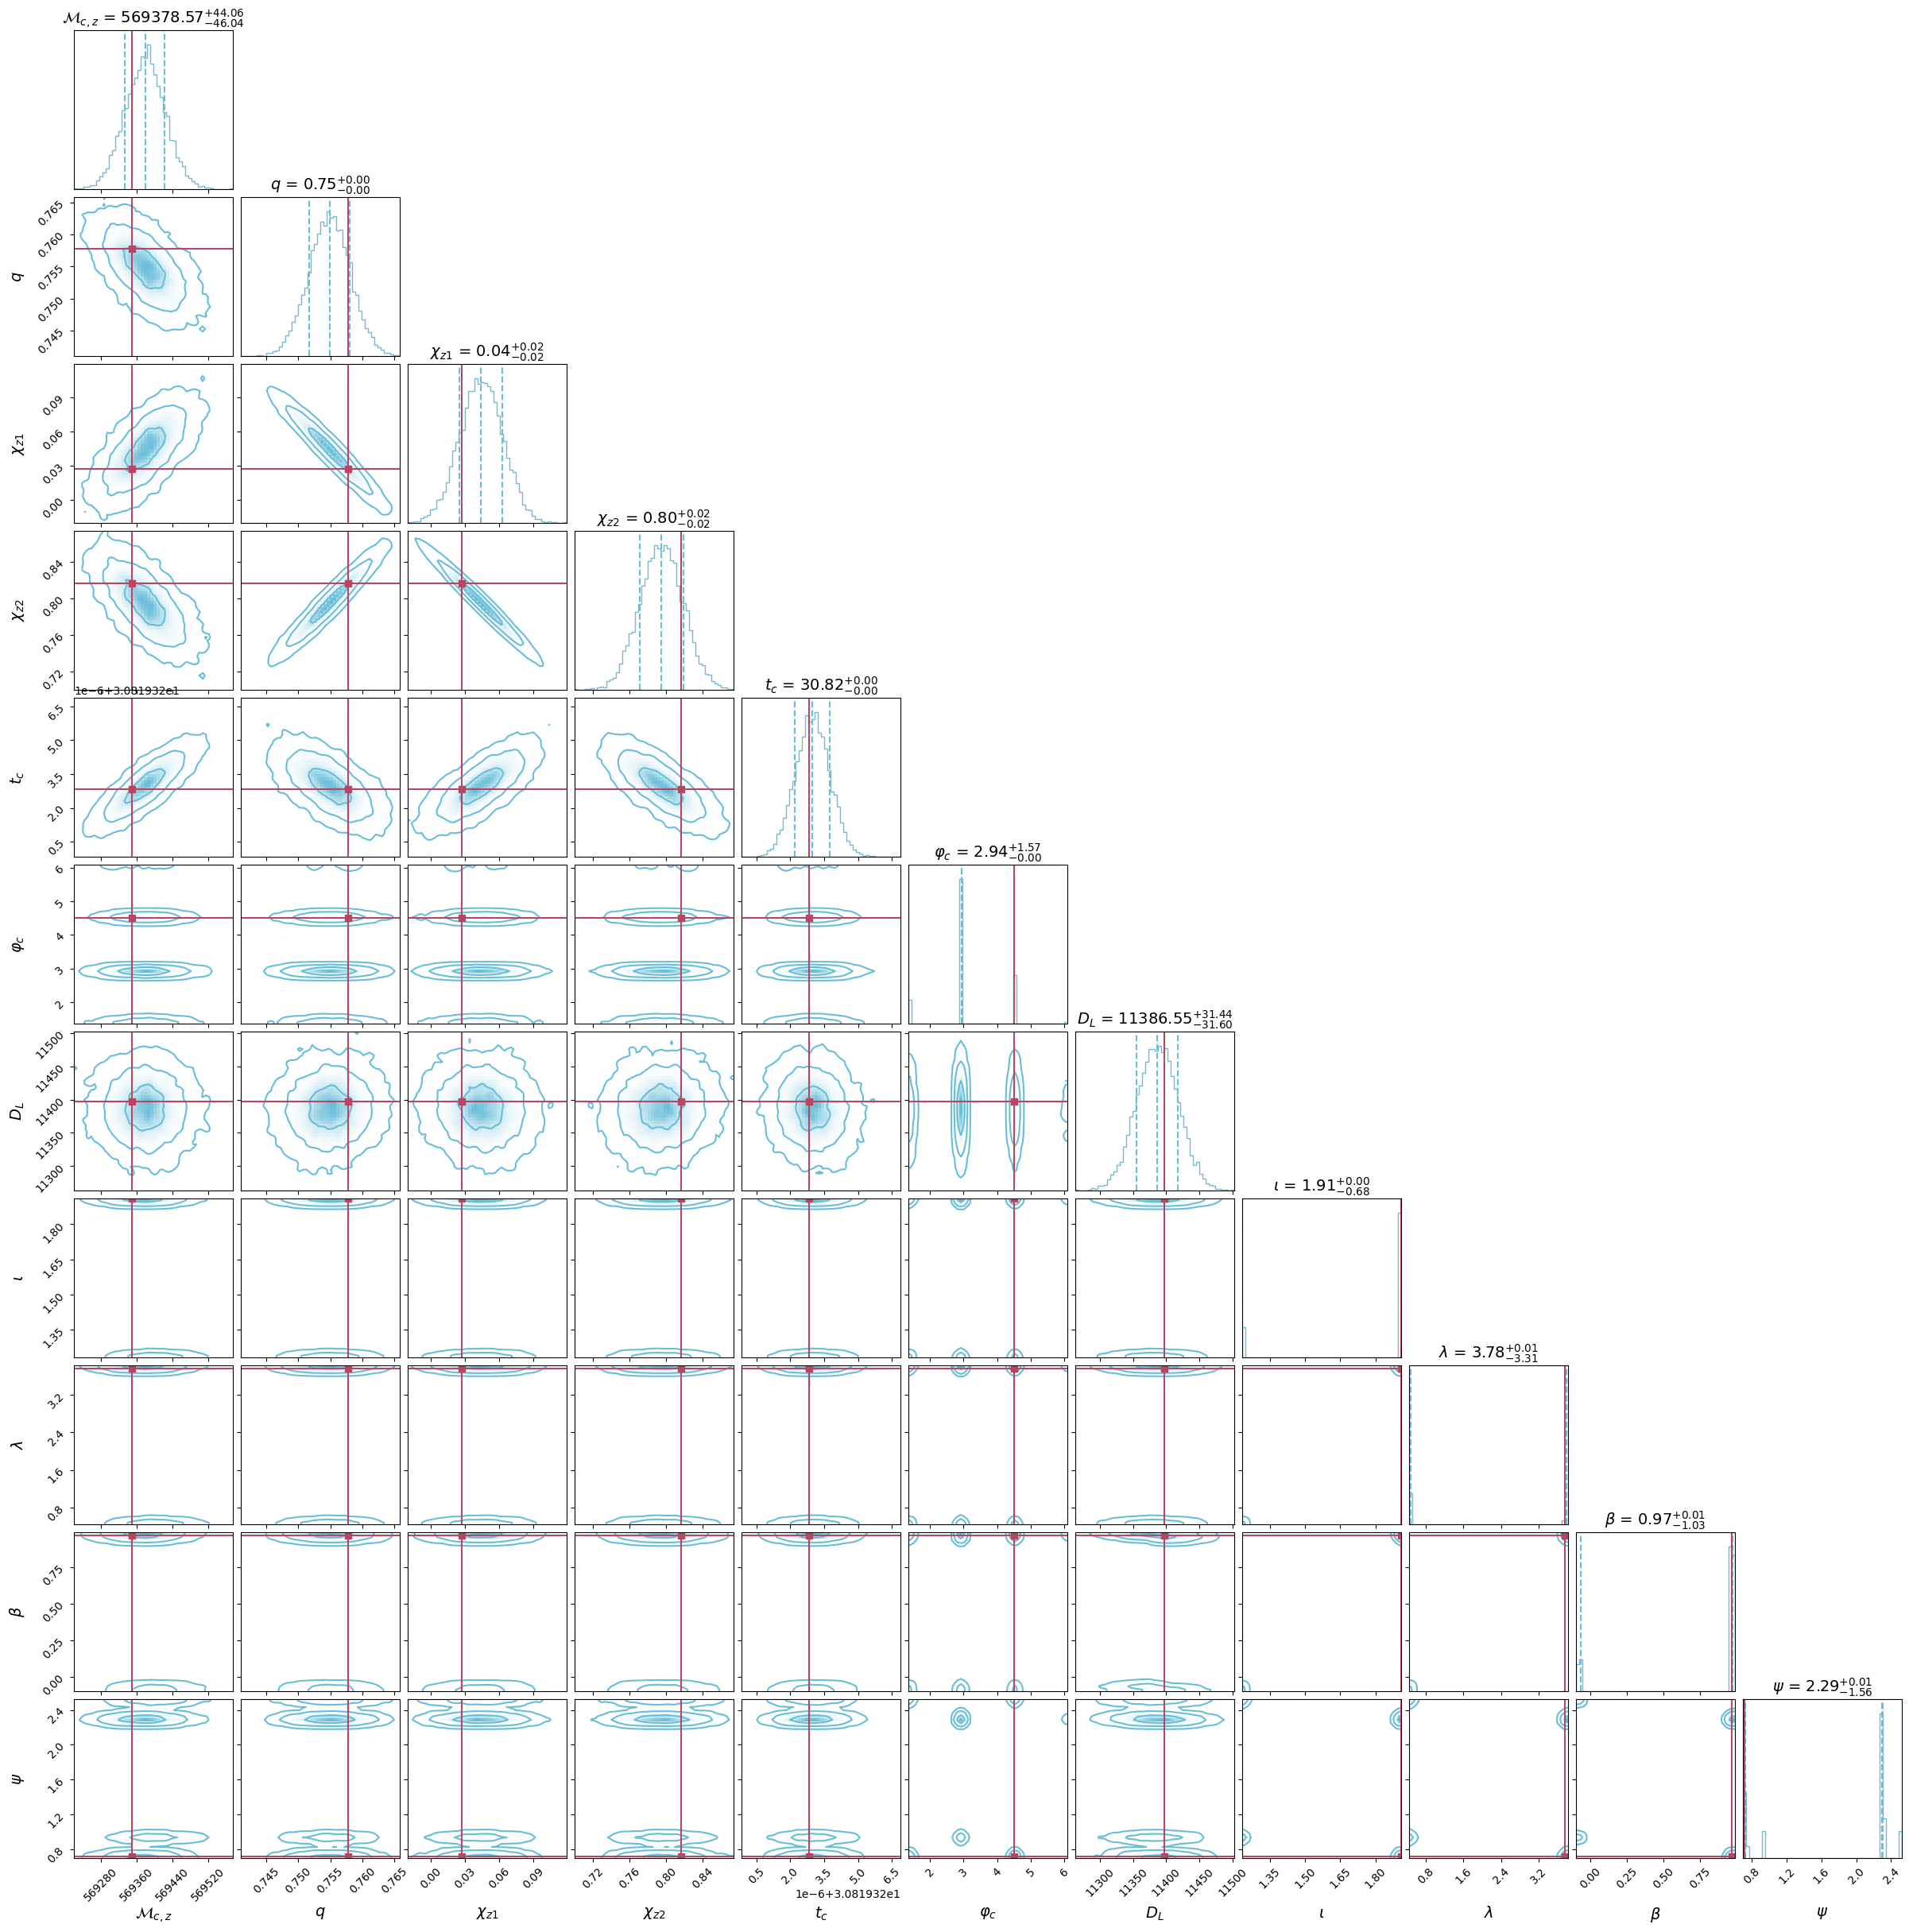

In [30]:
burnin=100
thin = 10

samp = ensemble.get_chain(discard=burnin, thin=thin)['model_0'][:, 0, :, :, :].reshape(-1, ndim)
print("sample shape:", samp.shape)
# samp = samp[-10000:, :] # use the last 10000 points 

plt.figure()
corner(
    np.array(list(ParamArr2ParamDict(samp.T).values())).T, 
    bins=50, 
    color=BLUE, 
    labels=labels, 
    label_kwargs={'fontsize': 14}, 
    truths=np.array(list(mbhb_parameters.values())),
    truth_color=RED,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_kwargs={'fontsize':14},
    levels = (1. - np.exp(-1.**2/2), 1. - np.exp(-2.**2/2), 1. - np.exp(-3.**2/2)),
    # levels = (1. - np.exp(-1.**2/2), 1. - np.exp(-2.**2/2), ),
    smooth=0.9, # default for bilby: smooth = 0.9, bins = 50 
    plot_density=True, # whether to show the density of samples with colors 
    plot_datapoints=False, # whether to plot individual data points 
    fill_contours=False, # whether to fill the corners 
    );


plt.savefig("./Posterior_of_full_workflow.pdf")

In [31]:
header = param_names[0]
for i in range(len(param_names)-1):
    header += " " + param_names[i+1]
    
np.savetxt(
    fname="./MCMC_samples_full_workflow.txt",
    X=np.array(list(ParamArr2ParamDict(samp.T).values())).T,
    header=header, 
)